# Análise estatística dos depósitos do Cofrinho Invista+

**Disciplina:** Estatística (PI do 4º semestre, DSM, Fatec Franca)

**Pergunta:** como as crianças e famílias usam o cofrinho? Qual é o depósito típico, quanto ele varia, em que dias a chance de guardar dinheiro é maior e quando a meta será atingida?

**Dados:** cada linha de `depositos.csv` é um depósito registrado pelo cofrinho (ESP32) e gravado pela API no Firestore. O arquivo é gerado pelo botão *Baixar CSV* da tela de Estatísticas do site.

| Coluna | Significado |
| --- | --- |
| `registradoEm` | Data e hora do depósito (UTC) |
| `valorCentavos` | Valor depositado em centavos |
| `forma` | `moeda` ou `cedula` |
| `pesoGramas` | Peso total do cofre medido pela célula de carga após o depósito |
| `origem` | `sensor` (cofrinho real) ou `simulado` (gerado por `scripts/simular-depositos.js`) |

> Nesta versão os dados são **simulados**. Ao coletar os depósitos do piloto com as famílias, substitua o CSV e execute o notebook de novo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({'figure.figsize': (9, 4), 'axes.grid': True, 'grid.alpha': 0.3})
AZUL, VERDE, LARANJA = '#004a9f', '#28a745', '#e67e22'
META_REAIS = 150.00
DIAS_ATE_A_META = 60


def num(valor, casas=2):
    return f'{valor:,.{casas}f}'.replace(',', ' ').replace('.', ',').replace(' ', '.')


def brl(valor):
    return f'R$ {num(valor, 2)}'


dados = pd.read_csv('depositos.csv')
dados['registradoEm'] = pd.to_datetime(dados['registradoEm'], utc=True).dt.tz_convert('America/Sao_Paulo')
dados['valor'] = dados['valorCentavos'] / 100
dados['dia'] = dados['registradoEm'].dt.date
dados['diaSemana'] = dados['registradoEm'].dt.dayofweek
dados['fimDeSemana'] = dados['diaSemana'] >= 5
dados = dados.sort_values('registradoEm').reset_index(drop=True)
valores = dados['valor']
print(f'{len(dados)} depósitos de {dados.dia.min()} a {dados.dia.max()}')
print(dados['origem'].value_counts().to_string())
dados.head()

67 depósitos de 2026-07-29 a 2026-09-25
origem
simulado    67


,registradoEm,valorCentavos,forma,pesoGramas,origem,valor,dia,diaSemana,fimDeSemana
0,2026-07-29 18:45:39-03:00,25,moeda,7.5,simulado,0.25,2026-07-29,2,False
1,2026-07-30 09:12:24-03:00,10,moeda,12.2,simulado,0.10,2026-07-30,3,False
2,2026-07-30 12:05:47-03:00,500,cedula,13.2,simulado,5.00,2026-07-30,3,False
3,2026-07-30 15:56:12-03:00,200,cedula,14.2,simulado,2.00,2026-07-30,3,False
4,2026-08-02 12:27:09-03:00,5,moeda,33.2,simulado,0.05,2026-08-02,6,True


## 1. Distribuição de frequências do valor depositado

In [2]:
tabela = valores.value_counts().sort_index().to_frame('frequência')
tabela['relativa (%)'] = (tabela['frequência'] / len(valores) * 100).round(2)
tabela['acumulada'] = tabela['frequência'].cumsum()
tabela['relativa acumulada (%)'] = tabela['relativa (%)'].cumsum().round(2)
tabela.index = [f'{brl(v)}'.replace('.', ',') for v in tabela.index]
tabela

,frequência,relativa (%),acumulada,relativa acumulada (%)
"R$ 0,05",9,13.43,9,13.43
"R$ 0,10",12,17.91,21,31.34
"R$ 0,25",13,19.40,34,50.74
"R$ 0,50",8,11.94,42,62.68
"R$ 1,00",15,22.39,57,85.07
"R$ 2,00",4,5.97,61,91.04
"R$ 5,00",5,7.46,66,98.50
"R$ 10,00",1,1.49,67,99.99


## 2. Medidas de tendência central

In [3]:
media = valores.mean()
mediana = valores.median()
modas = valores.mode().tolist()
print(f'Média: {brl(media)}')
print(f'Mediana: {brl(mediana)}')
print(f'Moda: {", ".join(f"{brl(m)}" for m in modas)} ({"unimodal" if len(modas) == 1 else "multimodal"})')

Média: R$ 1,00
Mediana: R$ 0,25
Moda: R$ 1,00 (unimodal)


## 3. Medidas de dispersão e separatrizes

In [4]:
dp_pop = valores.std(ddof=0)
dp_amostral = valores.std(ddof=1)
q1, q2, q3 = valores.quantile([0.25, 0.5, 0.75])
p10, p90 = valores.quantile([0.10, 0.90])
print(f'Amplitude: {brl(valores.max() - valores.min())} (de {brl(valores.min())} a {brl(valores.max())})')
print(f'Variância populacional: {num(valores.var(ddof=0), 4)}')
print(f'Desvio padrão populacional: {brl(dp_pop)} e amostral: {brl(dp_amostral)}')
print(f'Coeficiente de variação: {num(dp_pop / media * 100, 1)}%')
print(f'Quartis: Q1 = {brl(q1)}, Q2 = {brl(q2)}, Q3 = {brl(q3)}')
print(f'Percentis: P10 = {brl(p10)}, P90 = {brl(p90)}')

Amplitude: R$ 9,95 (de R$ 0,05 a R$ 10,00)
Variância populacional: 2,8680
Desvio padrão populacional: R$ 1,69 e amostral: R$ 1,71
Coeficiente de variação: 169,6%
Quartis: Q1 = R$ 0,10, Q2 = R$ 0,25, Q3 = R$ 1,00
Percentis: P10 = R$ 0,05, P90 = R$ 2,00


## 4. Assimetria e curtose

Classificação da assimetria: |As| < 0,15 simétrica; de 0,15 a 1 moderada; acima de 1 forte. Curtose percentílica: 0,263 é a referência da curva normal (mesocúrtica); abaixo disso a distribuição é leptocúrtica e acima, platicúrtica.

In [5]:
def classificar(coeficiente):
    intensidade = abs(coeficiente)
    if intensidade < 0.15:
        return 'simétrica'
    forca = 'moderada' if intensidade < 1 else 'forte'
    lado = 'positiva (à direita)' if coeficiente > 0 else 'negativa (à esquerda)'
    return f'assimetria {forca} {lado}'

pearson1 = (media - modas[0]) / dp_pop if len(modas) == 1 else float('nan')
pearson2 = 3 * (media - mediana) / dp_pop
fisher = stats.skew(valores, bias=True)
bowley = (q3 + q1 - 2 * q2) / (q3 - q1)
curtose_percentilica = (q3 - q1) / (2 * (p90 - p10))
excesso = stats.kurtosis(valores, fisher=True, bias=True)
print(f'Pearson 1: {num(pearson1, 3)}')
print(f'Pearson 2: {num(pearson2, 3)} → {classificar(pearson2)}')
print(f'Fisher: {num(fisher, 3)}')
print(f'Bowley: {num(bowley, 3)}')
print(f'Curtose percentílica: {num(curtose_percentilica, 3)} → {"leptocúrtica" if curtose_percentilica < 0.263 else "platicúrtica" if curtose_percentilica > 0.263 else "mesocúrtica"}')
print(f'Excesso de curtose (momentos): {num(excesso, 3)}')

Pearson 1: -0,001
Pearson 2: 1,326 → assimetria forte positiva (à direita)
Fisher: 3,168
Bowley: 0,667
Curtose percentílica: 0,231 → leptocúrtica
Excesso de curtose (momentos): 11,282


## 5. Gráficos da distribuição

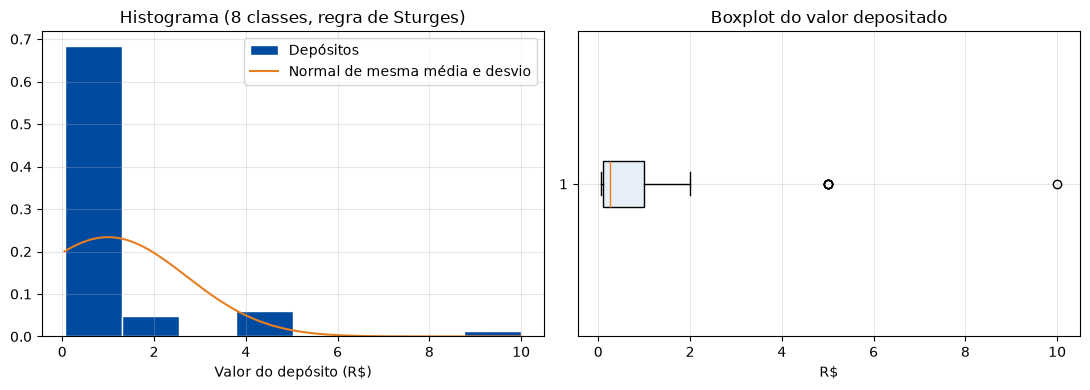

In [6]:
classes = int(np.ceil(1 + np.log2(len(valores))))
fig, eixos = plt.subplots(1, 2, figsize=(11, 4))
eixos[0].hist(valores, bins=classes, color=AZUL, edgecolor='white', density=True, label='Depósitos')
x = np.linspace(valores.min(), valores.max(), 200)
eixos[0].plot(x, stats.norm.pdf(x, media, dp_amostral), color=LARANJA, label='Normal de mesma média e desvio')
eixos[0].set_title(f'Histograma ({classes} classes, regra de Sturges)')
eixos[0].set_xlabel('Valor do depósito (R$)')
eixos[0].legend()
eixos[1].boxplot(valores, orientation='horizontal', patch_artist=True, boxprops={'facecolor': '#e6eef8'})
eixos[1].set_title('Boxplot do valor depositado')
eixos[1].set_xlabel('R$')
plt.tight_layout()
plt.show()

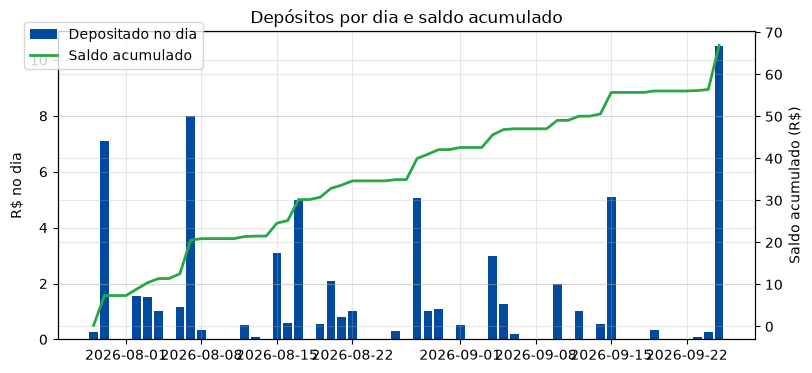

In [7]:
diario = dados.groupby('dia')['valor'].sum()
todos_os_dias = pd.date_range(dados['dia'].min(), dados['dia'].max(), freq='D').date
diario = diario.reindex(todos_os_dias, fill_value=0)
fig, eixo = plt.subplots()
eixo.bar(diario.index, diario.values, color=AZUL, label='Depositado no dia')
eixo2 = eixo.twinx()
eixo2.plot(diario.index, diario.cumsum().values, color=VERDE, linewidth=2, label='Saldo acumulado')
eixo.set_ylabel('R$ no dia')
eixo2.set_ylabel('Saldo acumulado (R$)')
eixo.set_title('Depósitos por dia e saldo acumulado')
fig.legend(loc='upper left', bbox_to_anchor=(0.08, 0.92))
plt.show()

## 6. Probabilidades

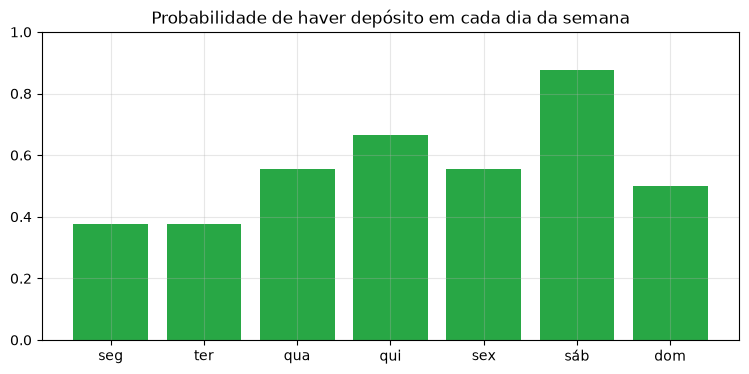

P(depósito na seg) = 0,38
P(depósito na ter) = 0,38
P(depósito na qua) = 0,56
P(depósito na qui) = 0,67
P(depósito na sex) = 0,56
P(depósito na sáb) = 0,88
P(depósito na dom) = 0,50

P(um depósito ser de R$ 1,00 ou mais) = 0,37
Saldo: R$ 66,90; meta: R$ 150,00; faltam R$ 83,10
Depósito diário: média R$ 1,13, desvio R$ 2,15
P(atingir a meta em 60 dias) ≈ 18,26% (aproximação normal pelo Teorema Central do Limite)


In [8]:
nomes = ['seg', 'ter', 'qua', 'qui', 'sex', 'sáb', 'dom']
dias_do_periodo = pd.Series(pd.to_datetime(todos_os_dias)).dt.dayofweek
dias_com_deposito = pd.Series(pd.to_datetime(diario[diario > 0].index)).dt.dayofweek
probabilidade = (dias_com_deposito.value_counts() / dias_do_periodo.value_counts()).reindex(range(7), fill_value=0)
plt.bar(nomes, probabilidade.values, color=VERDE)
plt.ylim(0, 1)
plt.title('Probabilidade de haver depósito em cada dia da semana')
plt.show()
for nome, p in zip(nomes, probabilidade.values):
    print(f'P(depósito na {nome}) = {num(p, 2)}')

p_um_real = (valores >= 1).mean()
print(f'\nP(um depósito ser de R$ 1,00 ou mais) = {num(p_um_real, 2)}')

saldo = valores.sum()
falta = max(META_REAIS - saldo, 0)
mu, sigma = diario.mean(), diario.std(ddof=1)
z = (falta - mu * DIAS_ATE_A_META) / (sigma * np.sqrt(DIAS_ATE_A_META))
p_meta = 1 - stats.norm.cdf(z)
print(f'Saldo: {brl(saldo)}; meta: {brl(META_REAIS)}; faltam {brl(falta)}')
print(f'Depósito diário: média {brl(mu)}, desvio {brl(sigma)}')
print(f'P(atingir a meta em {DIAS_ATE_A_META} dias) ≈ {num(p_meta * 100, 2)}% (aproximação normal pelo Teorema Central do Limite)')

## 7. Regressão linear

**Tendência:** saldo acumulado em função dos dias desde o primeiro depósito.

**Calibração:** saldo acumulado em moedas em função do peso medido pela balança do cofrinho. Se a relação for forte, o peso serve para conferir o valor guardado.

Saldo = 7,55 + 0,97 × dias   (r = 0,983, R² = 0,966)
Pela reta, o saldo chega a R$ 150,00 cerca de 146 dias após o primeiro depósito.
Saldo em moedas = 0,31 + 0,0682 × peso   (R² = 0,991)


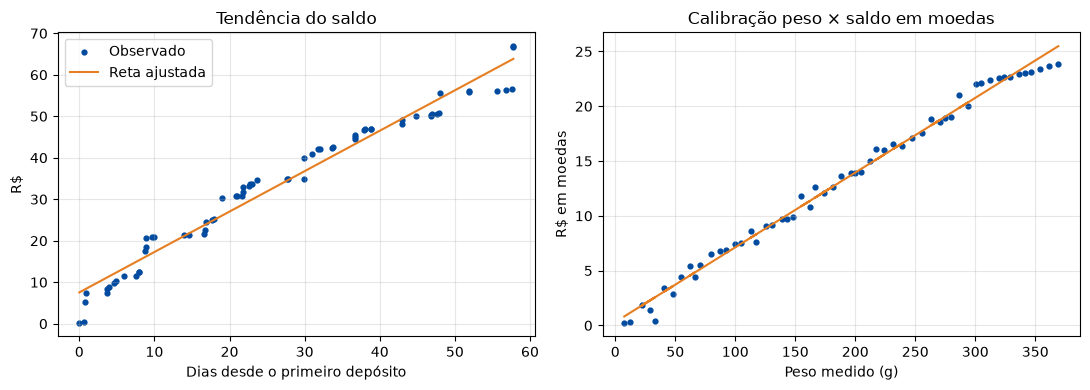

In [9]:
dias_desde_inicio = (dados['registradoEm'] - dados['registradoEm'].iloc[0]).dt.total_seconds() / 86400
saldo_acumulado = valores.cumsum()
tendencia = stats.linregress(dias_desde_inicio, saldo_acumulado)
print(f'Saldo = {num(tendencia.intercept, 2)} + {num(tendencia.slope, 2)} × dias   (r = {num(tendencia.rvalue, 3)}, R² = {num(tendencia.rvalue ** 2, 3)})')
dias_para_meta = (META_REAIS - tendencia.intercept) / tendencia.slope
print(f'Pela reta, o saldo chega a {brl(META_REAIS)} cerca de {num(dias_para_meta, 0)} dias após o primeiro depósito.')

moedas = dados[dados['forma'] == 'moeda'].copy()
moedas['saldoMoedas'] = moedas['valor'].cumsum()
calibracao = stats.linregress(moedas['pesoGramas'], moedas['saldoMoedas'])
print(f'Saldo em moedas = {num(calibracao.intercept, 2)} + {num(calibracao.slope, 4)} × peso   (R² = {num(calibracao.rvalue ** 2, 3)})')

fig, eixos = plt.subplots(1, 2, figsize=(11, 4))
eixos[0].scatter(dias_desde_inicio, saldo_acumulado, s=12, color=AZUL, label='Observado')
eixos[0].plot(dias_desde_inicio, tendencia.intercept + tendencia.slope * dias_desde_inicio, color=LARANJA, label='Reta ajustada')
eixos[0].set_title('Tendência do saldo')
eixos[0].set_xlabel('Dias desde o primeiro depósito')
eixos[0].set_ylabel('R$')
eixos[0].legend()
eixos[1].scatter(moedas['pesoGramas'], moedas['saldoMoedas'], s=12, color=AZUL)
eixos[1].plot(moedas['pesoGramas'], calibracao.intercept + calibracao.slope * moedas['pesoGramas'], color=LARANJA)
eixos[1].set_title('Calibração peso × saldo em moedas')
eixos[1].set_xlabel('Peso medido (g)')
eixos[1].set_ylabel('R$ em moedas')
plt.tight_layout()
plt.show()

## 8. Inferência

**Intervalo de confiança de 95%** para o valor médio de um depósito (t de Student).

**Teste t de Welch:** H0: o valor médio dos depósitos no fim de semana é igual ao dos dias úteis; H1: são diferentes (α = 5%).

In [10]:
n = len(valores)
erro_padrao = dp_amostral / np.sqrt(n)
t_critico = stats.t.ppf(0.975, n - 1)
print(f'IC 95% da média: {brl(media - t_critico * erro_padrao)} a {brl(media + t_critico * erro_padrao)} (t = {num(t_critico, 3)}, gl = {n - 1})')

fim_de_semana = dados.loc[dados['fimDeSemana'], 'valor']
dias_uteis = dados.loc[~dados['fimDeSemana'], 'valor']
teste = stats.ttest_ind(fim_de_semana, dias_uteis, equal_var=False)
print(f'Média no fim de semana: {brl(fim_de_semana.mean())} (n = {len(fim_de_semana)})')
print(f'Média nos dias úteis: {brl(dias_uteis.mean())} (n = {len(dias_uteis)})')
print(f't = {num(teste.statistic, 3)}, p = {num(teste.pvalue, 4)}')
print('Rejeita H0 a 5%.' if teste.pvalue < 0.05 else 'Não rejeita H0 a 5%.')

IC 95% da média: R$ 0,58 a R$ 1,41 (t = 1,997, gl = 66)
Média no fim de semana: R$ 0,55 (n = 21)
Média nos dias úteis: R$ 1,20 (n = 46)
t = -2,075, p = 0,0426
Rejeita H0 a 5%.


## 9. Conferência com a API

A API calcula as mesmas medidas em `lib/estatistica.js` (rota `GET /api/dispositivos/{id}/estatisticas`), e os testes automatizados comparam os resultados com o scipy. Assim, o site, o app e este notebook mostram os mesmos números para os mesmos dados.

## 10. Conclusões

> Texto escrito a partir dos dados simulados deste arquivo. Depois do piloto com as famílias, troque o `depositos.csv` pelos dados reais, execute o notebook de novo e atualize as conclusões.

1. **O depósito típico é pequeno e varia muito.** A mediana (R$ 0,25) fica bem abaixo da média (R$ 1,00), e o coeficiente de variação passa de 160%. A maior parte dos depósitos são moedas de pouco valor; poucas cédulas puxam a média para cima.

2. **A distribuição é assimétrica à direita e leptocúrtica.** Pearson 2 (1,33), Fisher (3,17) e Bowley (0,67) concordam: há uma cauda longa de valores altos. A curtose percentílica (0,231, abaixo de 0,263) e o excesso de curtose (11,3) mostram muitos depósitos concentrados nos valores baixos e alguns valores extremos (cédulas de R$ 5 e R$ 10). Por isso a mediana representa melhor o depósito típico do que a média. O Pearson 1 fica perto de zero porque a moda (R$ 1,00) coincide com a média, o que o torna pouco útil para estes dados.

3. **O dia da semana importa.** A chance de haver depósito é maior no sábado (0,88) e menor na segunda e na terça (0,38). O fim de semana, época de mesada e troco, é o momento em que a criança mais lembra do cofrinho.

4. **No fim de semana os depósitos são mais frequentes, porém menores.** O teste t de Welch (t = -2,08; p = 0,043) rejeita a hipótese de médias iguais a 5%: a média no fim de semana é R$ 0,55, contra R$ 1,20 nos dias úteis.

5. **Tendência e meta.** A reta de regressão explica 96,6% da variação do saldo (R² = 0,966), com crescimento de cerca de R$ 0,97 por dia. Nesse ritmo, a meta de R$ 150 seria atingida cerca de 146 dias após o primeiro depósito, e a chance de chegar lá nos próximos 60 dias é de apenas 18%. No app, isso vira uma orientação educativa: guardar um pouco mais por semana aproxima a meta.

6. **O sensor de peso é confiável para conferir o valor.** O peso medido explica 99,1% da variação do saldo em moedas (R² = 0,991), com cerca de R$ 0,07 por grama. A balança serve para conferir o valor guardado e detectar leituras erradas.

7. **Inferência sobre a média.** Com 95% de confiança, o valor médio de um depósito está entre R$ 0,58 e R$ 1,41. O intervalo é largo por causa da alta variabilidade; com mais dados reais do piloto ele fica mais estreito.
